<a href="https://colab.research.google.com/github/BelenUrdangarin/Integrador-Urdangarin---Olivera/blob/main/Pre_entrega_4(Urdangarin_Olivera).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Pre-entrega 4: Aprendizaje no Supervizado

Se aplicarán técnicas de agrupamiento no supervisado, como K-Means y DBSCAN con el fin de identificar patrones naturales entre países según sus variables ambientales representativas. Este análisis busca explorar si existen grupos en los datos que puedan corresponder con distintos niveles de impacto o progreso, sin necesidad de etiquetas predefinidas.

Consignas:

- Desarrollo de un modelo de aprendizaje no supervisado (clustering).
- Análisis exploratorio.
- Aplicación de algoritmo.
- Justificación de decisiones tomadas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
clim_pais_fil = pd.read_csv("https://raw.githubusercontent.com/BelenUrdangarin/Integrador-Urdangarin---Olivera/refs/heads/main/clim_pais_filtrado.csv", sep=',',on_bad_lines='skip',na_values="..") #Importo los datos
prod_ren_fil = pd.read_csv("https://raw.githubusercontent.com/BelenUrdangarin/Integrador-Urdangarin---Olivera/refs/heads/main/prod_ren_fil.csv", sep=',',on_bad_lines='skip',na_values="..") #Importo los datos
clim_pais_fil.shape


(50488, 15)

In [ ]:
print(clim_pais_fil.columns)  # Muestra las columnas disponibles

Index(['country', 'latitude', 'longitude', 'last_updated',
       'temperature_celsius', 'condition_text', 'wind_mph', 'pressure_mb',
       'precip_mm', 'cloud', 'uv_index', 'air_quality_Carbon_Monoxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'continent'],
      dtype='object')


Previo a la utilización de un algoritmo de aprendizaje no supervisado se deben normalizar los datos para que su media sea 0 y la desviación estandar igual a 1, lo que provoca que todas las variables se encuentren en la misma escala.
Escalar es importante porque muchos algoritmos de clustering usan distancias para agrupar muestras, entonces si una variables tiene un escala mucho mas grande que otra, ésta dominará en distancia.

In [ ]:
Clim_sc = clim_pais_fil.drop(columns=["country","continent","last_updated","condition_text"])
#Para escalar los datos tenemos que sacar aquellos que no contengan variables numericas
#Pero las almacenaremos para un analisis posterior.
print(Clim_sc)

       latitude  longitude  temperature_celsius  wind_mph  pressure_mb  \
0       34.5200    69.1800                 26.6       8.3       1012.0   
1       41.3300    19.8200                 19.0       6.9       1012.0   
2       42.5000     1.5200                  6.3       7.4       1007.0   
3       17.1200   -61.8500                 26.0       5.6       1013.0   
4      -34.5900   -58.6700                  8.0       2.2       1014.0   
...         ...        ...                  ...       ...          ...   
50483   41.3167    69.2500                 30.1      13.2       1019.0   
50484  -17.7333   168.3167                 26.2      13.4       1013.0   
50485   15.3547    44.2067                 26.9       9.8       1012.0   
50486  -15.4167    28.2833                 27.7       6.0       1014.0   
50487  -17.8178    31.0447                 24.7       7.4       1015.0   

       precip_mm  cloud  uv_index  air_quality_Carbon_Monoxide  \
0           0.00     30       7.0            

In [ ]:
scal = StandardScaler()
clim_scal = scal.fit_transform(Clim_sc) #dataset original
print(clim_scal)

[[ 0.59053006  0.78772162  0.44856323 ... -0.13699398 -0.35448372
  -0.1051929 ]
 [ 0.85846129  0.03448194 -0.40445749 ... -1.03828354 -0.67255501
  -0.27414106]
 [ 0.90449353 -0.24477832 -1.82990001 ... -1.29116334 -0.68998358
  -0.28169565]
 ...
 [-0.16350555  0.40662598  0.4822351  ... -0.47146535  0.08558753
   0.55576526]
 [-1.37416916  0.16363294  0.57202676 ...  0.86804114 -0.16429451
  -0.19385634]
 [-1.46863754  0.20577224  0.23530805 ...  0.52816636 -0.18041593
  -0.19766798]]


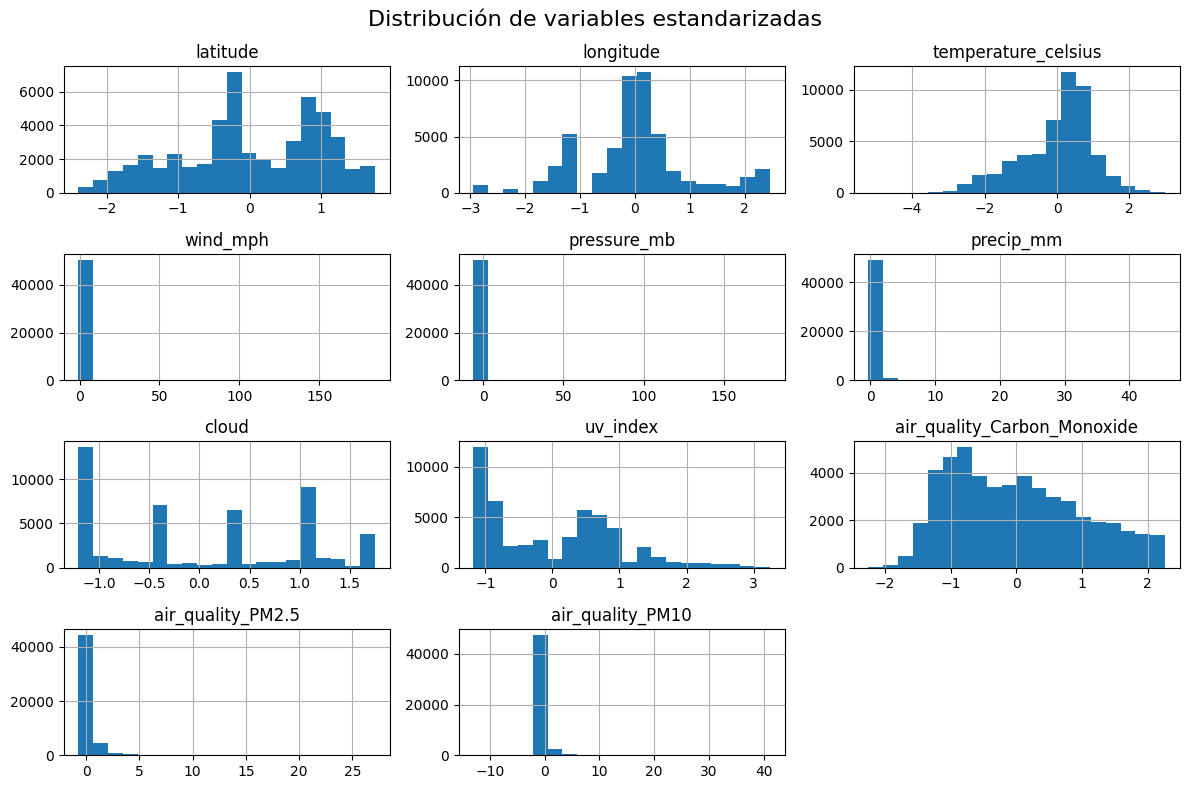

In [ ]:
clim_print = pd.DataFrame(clim_scal, columns=Clim_sc.columns)  # Usás las columnas originales

clim_print.hist(figsize=(12, 8), bins=20)
plt.suptitle('Distribución de variables estandarizadas', fontsize=16)
plt.tight_layout()
plt.show()

En la imagen se puede ver como para muchas variables como latitud, longitud, temperatura, calidad de aire e indice UV el resultado quedo bien centrado, con formas simetricas y distribución estandar. El resto de las variables se encuentran concentrados en valores bajos, lo que indica que la distribución original era sesgada. Se debera tener en cuenta esto en algoritmos sensibles a la forma de la distribución.

###K-means
Luego de escalar los datos, utilizaremos K-means para agrupar las variables. Como en la entrega anterior se buscó agruparlos en tres grupos, en esta entrega se utilizará el mismo principio para comparar los resultados obtenidos.

In [ ]:
Cmeans = KMeans(n_clusters=3, random_state=42)
clusters = Cmeans.fit_predict(clim_scal)
#Asignamos cada país a un cluster segun los patrones que el algoritmo encuentre
clim_pais_fil['Cluster'] = clusters #Sumamos las columnas de clusters al DF original


In [ ]:
# 1. Obtener los centroides
centroids = Cmeans.cluster_centers_

# 2. Calcular distancia euclídea de cada punto a su centroide
distances = np.linalg.norm(clim_scal - centroids[clusters], axis=1)

# 3. Añadir esa distancia al DataFrame
clim_pais_fil['dist_to_centroid'] = distances

# 4. Extraer, por ejemplo, los países más “atípicos”
outliers = clim_pais_fil.nlargest(2, 'dist_to_centroid')
print(outliers[['country','Cluster','dist_to_centroid']])

clim_pais_fil.loc[clim_pais_fil['country'].isin(['Burundi','Honduras'])]

perfiles = clim_pais_fil.groupby('Cluster').mean(numeric_only=True)
perfiles.loc[[0,1]]

        country  Cluster  dist_to_centroid
6390    Burundi        1        185.043937
38128  Honduras        0        178.398496


,latitude,longitude,temperature_celsius,wind_mph,pressure_mb,precip_mm,cloud,uv_index,air_quality_Carbon_Monoxide,air_quality_PM2.5,air_quality_PM10,dist_to_centroid
Cluster,,,,,,,,,,,,
0,41.561081,4.456585,11.839116,8.297330,1017.337321,0.071286,44.394295,1.721666,352.498965,16.905087,24.508301,2.156244
1,17.629381,20.339545,28.779432,9.552287,1012.541885,0.016411,16.364889,7.579608,285.009757,24.265756,81.071019,2.369458


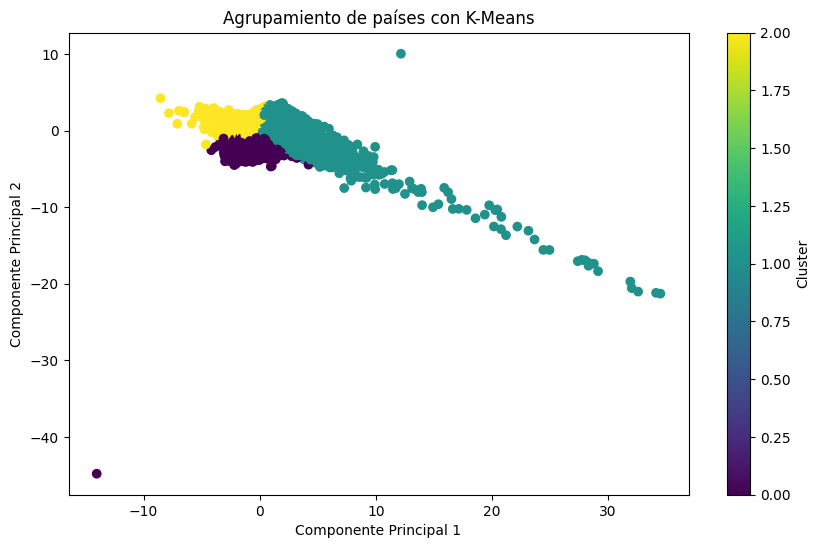

In [ ]:
#Graficamos los clusters
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(clim_scal)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Agrupamiento de países con K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
clim_pais_fil.groupby('Cluster').mean(numeric_only=True)

,latitude,longitude,temperature_celsius,wind_mph,pressure_mb,precip_mm,cloud,uv_index,air_quality_Carbon_Monoxide,air_quality_PM2.5,air_quality_PM10
Cluster,,,,,,,,,,,
0,41.561081,4.456585,11.839116,8.297330,1017.337321,0.071286,44.394295,1.721666,352.498965,16.905087,24.508301
1,17.629381,20.339545,28.779432,9.552287,1012.541885,0.016411,16.364889,7.579608,285.009757,24.265756,81.071019
2,4.724883,24.625316,24.372855,9.249928,1012.461079,0.323020,63.223453,2.812850,246.834478,8.244537,14.552560


- Cluster 0 combinación de templado y contaminado:
Zonas de clima fresco con contaminación de aire elevada, típicas de áreas industriales o urbanas de latitudes medias-altas.

- Cluster 1 combinación de clima cálido y contaminado:
Regiones de clima cálido extremo y seco, con alta radiación solar y niveles críticos de contaminación urbana.

- Cluster 2 combinación de clima tropical y no tan contaminado:
Áreas tropicales con cobertura nubosa y lluvias regulares, lo que ayuda a mantener niveles de contaminación y radiación UV más bajos.

In [ ]:
clim_pais_fil.groupby('Cluster')['country'].count()

,country
Cluster,
0,13708
1,18718
2,18062
